# Сравнение очищенных записей 3-9 с эталонами 1 и 2

Этот ноутбук:
- загружает очищенные EDF-файлы из `cleaned_data`;
- использует записи `1` и `2` как эталоны;
- сравнивает записи `3-9` с эталонами по спектрам мощности;
- считает, к какому эталону каждая запись ближе;
- выводит таблицу с метриками сходства и итоговой классификацией.


In [1]:
from pathlib import Path

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch


In [2]:
clean_dir = Path("cleaned_data")

file_1 = clean_dir / "1 open eyes_clean.edf"
file_2 = clean_dir / "2 closed eyes_clean.edf"

candidate_files = [
    clean_dir / "3 2026.01.24-16.16.21.085_clean.edf",
    clean_dir / "4 2026.01.24-16.18.47.499_clean.edf",
    clean_dir / "5 2026.01.24-16.38.37.757_clean.edf",
    clean_dir / "6 2026.01.24-16.41.01.794_clean.edf",
    clean_dir / "7 2026.01.24-16.53.06.041_clean.edf",
    clean_dir / "8 2026.01.24-17.03.42.427_clean.edf",
    clean_dir / "9 2026.01.24-17.05.59.615_clean.edf",
]


In [3]:
raw_1 = mne.io.read_raw_edf(file_1, preload=True, verbose="ERROR")
raw_2 = mne.io.read_raw_edf(file_2, preload=True, verbose="ERROR")

candidate_raws = {path.name: mne.io.read_raw_edf(path, preload=True, verbose="ERROR") for path in candidate_files}

print("Reference 1 channels:", raw_1.ch_names)
print("Reference 2 channels:", raw_2.ch_names)


Reference 1 channels: ['O1', 'T3', 'Fp1', 'Fp2', 'T4', 'O2']
Reference 2 channels: ['O1', 'T3', 'Fp1', 'Fp2', 'T4', 'O2']


In [4]:
channels = ["O1", "T3", "Fp1", "Fp2", "T4", "O2"]
freq_range = (1, 30)
alpha_band = (8, 13)
beta_band = (13, 30)


In [5]:
def compute_mean_psd(raw, channels, freq_range=(1, 30)):
    sfreq = raw.info["sfreq"]
    psd_list = []
    freqs_ref = None

    for ch in channels:
        signal = raw.copy().pick([ch]).get_data()[0]
        freqs, psd = welch(signal, fs=sfreq, nperseg=min(len(signal), int(sfreq * 4)))
        mask = (freqs >= freq_range[0]) & (freqs <= freq_range[1])

        if freqs_ref is None:
            freqs_ref = freqs[mask]

        psd_list.append(psd[mask])

    mean_psd = np.mean(np.vstack(psd_list), axis=0)
    return freqs_ref, mean_psd


In [6]:
def spectral_distance(psd_a, psd_b):
    psd_a = np.asarray(psd_a)
    psd_b = np.asarray(psd_b)
    return np.linalg.norm(psd_a - psd_b)


In [7]:
def band_power(freqs, psd, fmin, fmax):
    mask = (freqs >= fmin) & (freqs <= fmax)
    return np.trapezoid(psd[mask], freqs[mask])


In [8]:
freqs_1, psd_1 = compute_mean_psd(raw_1, channels, freq_range=freq_range)
freqs_2, psd_2 = compute_mean_psd(raw_2, channels, freq_range=freq_range)

alpha_beta_ratio_1 = band_power(freqs_1, psd_1, *alpha_band) / band_power(freqs_1, psd_1, *beta_band)
alpha_beta_ratio_2 = band_power(freqs_2, psd_2, *alpha_band) / band_power(freqs_2, psd_2, *beta_band)


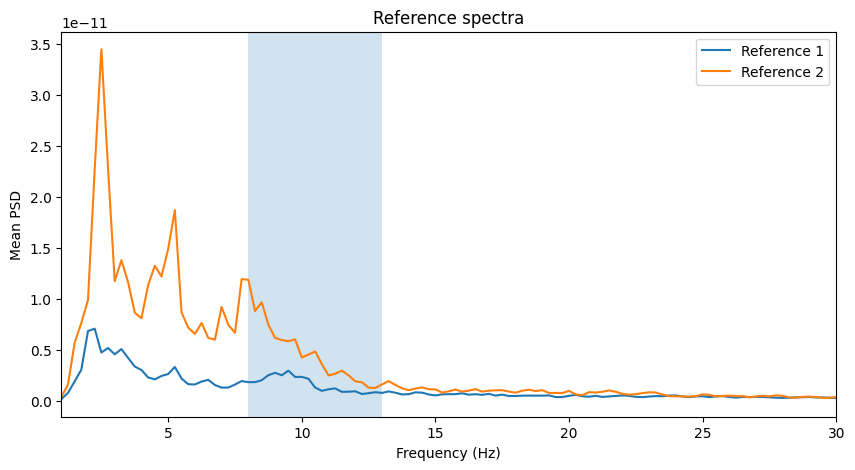

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(freqs_1, psd_1, label="Reference 1")
plt.plot(freqs_2, psd_2, label="Reference 2")
plt.axvspan(alpha_band[0], alpha_band[1], alpha=0.2)
plt.xlim(freq_range)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Mean PSD")
plt.title("Reference spectra")
plt.legend()
plt.show()


In [10]:
results = []

for file_name, raw_candidate in candidate_raws.items():
    freqs_c, psd_c = compute_mean_psd(raw_candidate, channels, freq_range=freq_range)

    dist_to_1 = spectral_distance(psd_c, psd_1)
    dist_to_2 = spectral_distance(psd_c, psd_2)

    alpha_beta_ratio_c = band_power(freqs_c, psd_c, *alpha_band) / band_power(freqs_c, psd_c, *beta_band)

    assigned_reference = "1" if dist_to_1 < dist_to_2 else "2"

    results.append(
        {
            "file": file_name,
            "distance_to_1": dist_to_1,
            "distance_to_2": dist_to_2,
            "alpha_beta_ratio": alpha_beta_ratio_c,
            "reference_1_alpha_beta_ratio": alpha_beta_ratio_1,
            "reference_2_alpha_beta_ratio": alpha_beta_ratio_2,
            "assigned_reference": assigned_reference,
        }
    )

results_df = pd.DataFrame(results)
results_df


,file,distance_to_1,distance_to_2,alpha_beta_ratio,reference_1_alpha_beta_ratio,reference_2_alpha_beta_ratio,assigned_reference
0,3 2026.01.24-16.16.21.085_clean.edf,7.234976e-08,7.230447e-08,0.895065,0.923566,1.674802,2
1,4 2026.01.24-16.18.47.499_clean.edf,3.643417e-11,3.526083e-11,1.716805,0.923566,1.674802,2
2,5 2026.01.24-16.38.37.757_clean.edf,5.056778e-11,4.272964e-11,1.919218,0.923566,1.674802,2
3,6 2026.01.24-16.41.01.794_clean.edf,9.448456e-11,8.475944e-11,0.963902,0.923566,1.674802,2
4,7 2026.01.24-16.53.06.041_clean.edf,1.290008e-11,6.569511e-11,0.635886,0.923566,1.674802,1
5,8 2026.01.24-17.03.42.427_clean.edf,1.665240e-11,5.788901e-11,1.501495,0.923566,1.674802,1
6,9 2026.01.24-17.05.59.615_clean.edf,1.189000e-06,1.188986e-06,0.114345,0.923566,1.674802,2


In [11]:
results_df = results_df.sort_values("file").reset_index(drop=True)
results_df


,file,distance_to_1,distance_to_2,alpha_beta_ratio,reference_1_alpha_beta_ratio,reference_2_alpha_beta_ratio,assigned_reference
0,3 2026.01.24-16.16.21.085_clean.edf,7.234976e-08,7.230447e-08,0.895065,0.923566,1.674802,2
1,4 2026.01.24-16.18.47.499_clean.edf,3.643417e-11,3.526083e-11,1.716805,0.923566,1.674802,2
2,5 2026.01.24-16.38.37.757_clean.edf,5.056778e-11,4.272964e-11,1.919218,0.923566,1.674802,2
3,6 2026.01.24-16.41.01.794_clean.edf,9.448456e-11,8.475944e-11,0.963902,0.923566,1.674802,2
4,7 2026.01.24-16.53.06.041_clean.edf,1.290008e-11,6.569511e-11,0.635886,0.923566,1.674802,1
5,8 2026.01.24-17.03.42.427_clean.edf,1.665240e-11,5.788901e-11,1.501495,0.923566,1.674802,1
6,9 2026.01.24-17.05.59.615_clean.edf,1.189000e-06,1.188986e-06,0.114345,0.923566,1.674802,2


In [12]:
for _, row in results_df.iterrows():
    print(row["file"])
    print("  distance to 1:", round(row["distance_to_1"], 6))
    print("  distance to 2:", round(row["distance_to_2"], 6))
    print("  alpha/beta:", round(row["alpha_beta_ratio"], 6))
    print("  assigned reference:", row["assigned_reference"])


3 2026.01.24-16.16.21.085_clean.edf
  distance to 1: 0.0
  distance to 2: 0.0
  alpha/beta: 0.895065
  assigned reference: 2
4 2026.01.24-16.18.47.499_clean.edf
  distance to 1: 0.0
  distance to 2: 0.0
  alpha/beta: 1.716805
  assigned reference: 2
5 2026.01.24-16.38.37.757_clean.edf
  distance to 1: 0.0
  distance to 2: 0.0
  alpha/beta: 1.919218
  assigned reference: 2
6 2026.01.24-16.41.01.794_clean.edf
  distance to 1: 0.0
  distance to 2: 0.0
  alpha/beta: 0.963902
  assigned reference: 2
7 2026.01.24-16.53.06.041_clean.edf
  distance to 1: 0.0
  distance to 2: 0.0
  alpha/beta: 0.635886
  assigned reference: 1
8 2026.01.24-17.03.42.427_clean.edf
  distance to 1: 0.0
  distance to 2: 0.0
  alpha/beta: 1.501495
  assigned reference: 1
9 2026.01.24-17.05.59.615_clean.edf
  distance to 1: 1e-06
  distance to 2: 1e-06
  alpha/beta: 0.114345
  assigned reference: 2


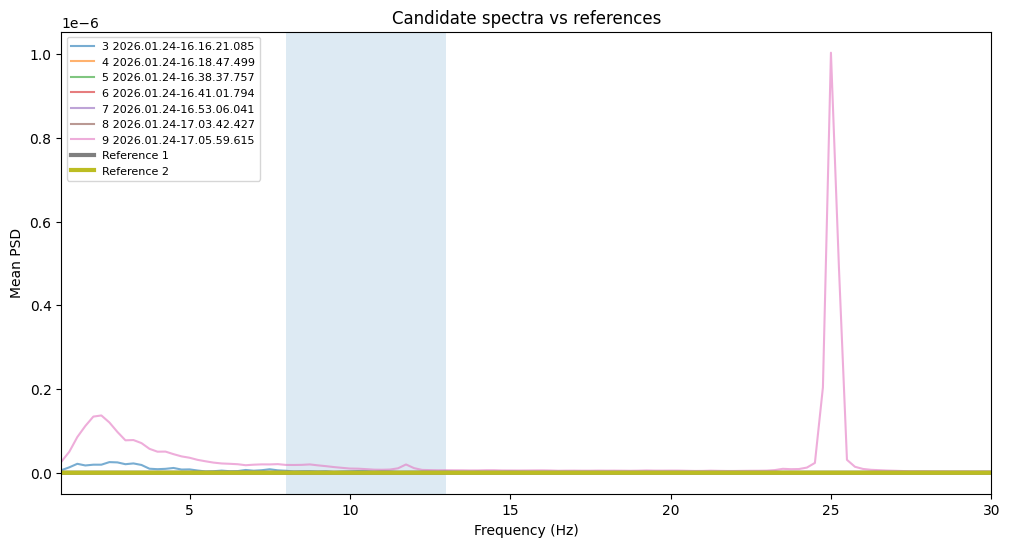

In [13]:
plt.figure(figsize=(12, 6))

for file_name, raw_candidate in candidate_raws.items():
    freqs_c, psd_c = compute_mean_psd(raw_candidate, channels, freq_range=freq_range)
    plt.plot(freqs_c, psd_c, alpha=0.6, label=file_name.split("_clean")[0])

plt.plot(freqs_1, psd_1, linewidth=3, label="Reference 1")
plt.plot(freqs_2, psd_2, linewidth=3, label="Reference 2")
plt.axvspan(alpha_band[0], alpha_band[1], alpha=0.15)
plt.xlim(freq_range)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Mean PSD")
plt.title("Candidate spectra vs references")
plt.legend(fontsize=8)
plt.show()


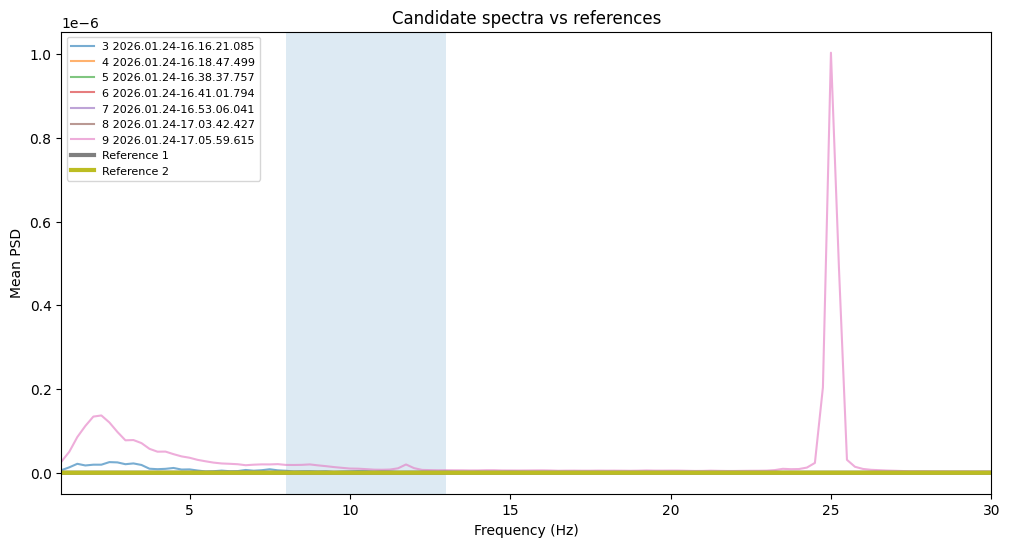

In [14]:
plt.figure(figsize=(12, 6))

for file_name, raw_candidate in candidate_raws.items():
    freqs_c, psd_c = compute_mean_psd(raw_candidate, channels, freq_range=freq_range)
    plt.plot(freqs_c, psd_c, alpha=0.6, label=file_name.split("_clean")[0])

plt.plot(freqs_1, psd_1, linewidth=3, label="Reference 1")
plt.plot(freqs_2, psd_2, linewidth=3, label="Reference 2")
plt.axvspan(alpha_band[0], alpha_band[1], alpha=0.15)
plt.xlim(freq_range)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Mean PSD")
plt.title("Candidate spectra vs references")
plt.legend(fontsize=8)
plt.show()
